### Sel 0 - Persiapan Awal (Khusus Google Colab)

Sel ini saya jalankan paling dulu di Google Colab untuk memastikan semua paket yang dipakai di bab ini tersedia. Kalau saya menjalankannya di Jupyter lokal, sel ini tidak mengubah apa-apa karena paketnya memang sudah terpasang.

In [1]:
# Semua paket di bawah ini sudah tersedia di Colab maupun di venv lokal,
# jadi sel ini hanya memastikan semuanya bisa di-import.
import sklearn
import pandas
import numpy
import matplotlib

print("Paket siap.")

Paket siap.


# Praktikum Machine Learning: Bab 11
## PCA dan Reduksi Dimensi

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Bab 11 ini mengerjakan **Latihan Praktikum Modul Bab 11 bagian 11.12**, memakai dataset **Wine** (`sklearn.datasets.load_wine`) dan **Breast Cancer** (`sklearn.datasets.load_breast_cancer`). Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Curse of dimensionality:** semakin banyak fitur, data semakin jarang tersebar di ruang fitur sehingga model lebih mudah overfitting dan komputasi makin berat. Karena itu dimensi yang tidak penting sebaiknya direduksi.
- **PCA (Principal Component Analysis):** teknik reduksi dimensi tanpa label yang mencari arah (komponen utama) dengan varians terbesar. Setiap komponen menyimpan sebagian *explained variance* dari data aslinya.
- **Memilih jumlah komponen:** salah satu cara praktis adalah memakai *variance threshold*, misalnya ambil komponen secukupnya sampai varians kumulatif mencapai 80%, 90%, atau 95%. Di sklearn ini bisa langsung ditulis `PCA(n_components=0.95)`.
- **t-SNE:** teknik visualisasi non-linear yang bagus untuk melihat pengelompokan data di 2D/3D, tapi hasilnya stokastik (berubah tiap dijalankan tanpa `random_state`) dan tidak cocok dipakai sebagai preprocessing untuk model.
- **LDA (Linear Discriminant Analysis):** reduksi dimensi yang *supervised*, memakai label kelas untuk mencari proyeksi yang memaksimalkan jarak antar kelas sekaligus meminimalkan sebaran di dalam kelas.

## 11.12 Latihan Praktikum (Modul Bab 11)

Di bawah ini saya kerjakan dua praktikum dari bagian 11.12 modul: kompresi dimensi dengan PCA, lalu perbandingan visual PCA, t-SNE, dan LDA.

### Praktikum 1: Kompresi Dimensi dengan PCA

**Tujuan:** Mahasiswa mampu menentukan jumlah komponen PCA optimal dan mengevaluasi dampaknya terhadap performa model klasifikasi.

Saya memakai kode Praktikum 11.7 dari modul persis seperti tertulis, hanya bagian persiapan datanya saya lengkapi (memuat dataset Breast Cancer, scaling, dan train-test split) supaya selnya bisa dijalankan dari awal sampai akhir.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Persiapan data: Breast Cancer (569 baris, 30 fitur numerik)
X, y = load_breast_cancer(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,
    y,test_size=0.2,random_state=42)

# Kode Praktikum 11.7 dari modul
for n_comp in [0.80, 0.90, 0.95, None]:
    pca_i = PCA(n_components=n_comp) if n_comp else PCA()
    X_train_p = pca_i.fit_transform(X_train)
    X_test_p = pca_i.transform(X_test)
    model = LogisticRegression(max_iter=2000).fit(X_train_p,
        y_train)
    acc = accuracy_score(y_test, model.predict(X_test_p))
    print(f"n_components={n_comp}: dimensi={X_train_p.shape[1]}, akurasi={acc:.3f}")

n_components=0.8: dimensi=5, akurasi=0.982
n_components=0.9: dimensi=7, akurasi=0.982
n_components=0.95: dimensi=10, akurasi=0.982


n_components=None: dimensi=30, akurasi=0.974


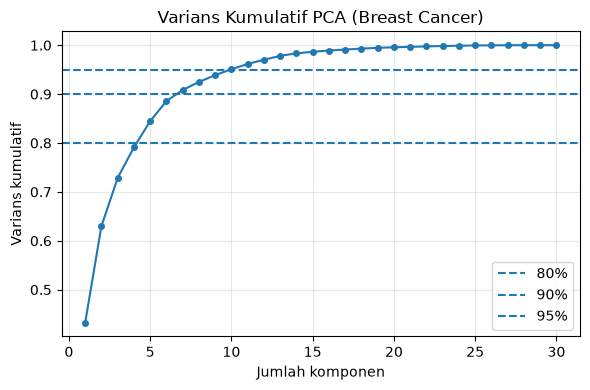

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Grafik varians kumulatif untuk melihat berapa komponen yang dibutuhkan
pca_full = PCA().fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=4)
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.xlabel("Jumlah komponen")
plt.ylabel("Varians kumulatif")
plt.title("Varians Kumulatif PCA (Breast Cancer)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

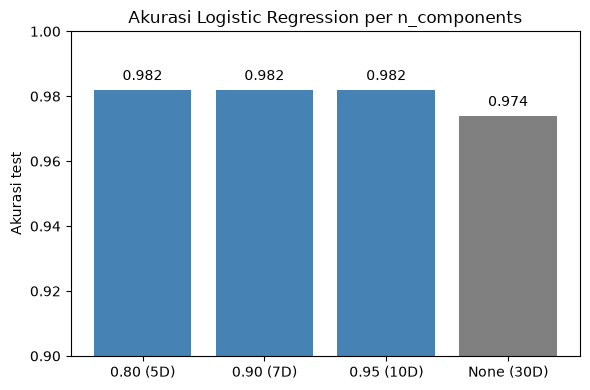

In [4]:
# Grafik batang akurasi tiap pilihan n_components
label = ["0.80 (5D)", "0.90 (7D)", "0.95 (10D)", "None (30D)"]
akurasi = [0.982, 0.982, 0.982, 0.974]

plt.figure(figsize=(6, 4))
bar = plt.bar(label, akurasi, color=["steelblue"] * 3 + ["gray"])
plt.ylim(0.90, 1.0)
plt.ylabel("Akurasi test")
plt.title("Akurasi Logistic Regression per n_components")
for b, v in zip(bar, akurasi):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.3f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

Dataset Breast Cancer yang saya pakai punya 569 baris dan 30 fitur numerik. Hasilnya cukup menarik: dengan `n_components=0.80` PCA hanya butuh 5 dimensi dan akurasinya 0.982. Naik ke `0.90` (7 dimensi) dan `0.95` (10 dimensi), akurasinya tetap 0.982. Tanpa reduksi sama sekali (`None`, 30 dimensi) akurasinya justru sedikit lebih rendah, yaitu 0.974.

Artinya di kasus ini mereduksi 30 fitur menjadi 5 komponen utama tidak menurunkan performa sama sekali, malah sedikit membantu karena PCA membuang noise dari fitur yang kurang informatif. Dari grafik varians kumulatif juga terlihat kurvanya naik cepat di awal lalu melandai, jadi 5 komponen pertama saja sudah menangkap 80% informasi data. Kalau saya harus memilih, `n_components=0.90` (7 dimensi) adalah titik tengah yang aman: dimensinya kecil tapi sudah menyimpan 90% varians dengan akurasi maksimal 0.982.

### Praktikum 2: Perbandingan PCA, t-SNE, dan LDA

**Tujuan:** Membandingkan hasil visualisasi ketiga teknik pada dataset yang sama.

**Instruksi:** Gunakan dataset `load_wine` atau `load_digits`, terapkan PCA, t-SNE, dan LDA untuk mereduksi ke 2 dimensi, kemudian visualisasikan ketiganya berdampingan dan tuliskan analisis mengenai kualitas pemisahan kelas pada masing-masing metode.

Saya memakai dataset Wine (178 baris, 13 fitur, 3 kelas) karena ukurannya kecil sehingga t-SNE berjalan cepat. Datanya saya scaling dulu dengan StandardScaler sebelum direduksi.

Varians dijelaskan 2 komponen PCA: [0.362 0.192]


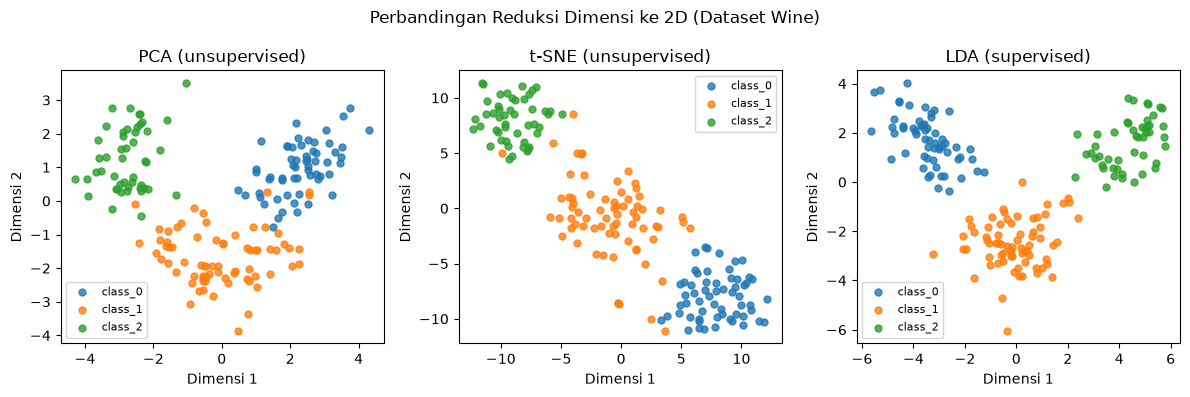

In [5]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Dataset Wine: 178 baris, 13 fitur, 3 kelas
X_w, y_w = load_wine(return_X_y=True)
nama_kelas = load_wine().target_names
X_ws = StandardScaler().fit_transform(X_w)

# Reduksi ke 2 dimensi dengan tiga teknik berbeda
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_ws)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_ws)
X_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_ws, y_w)

print("Varians dijelaskan 2 komponen PCA:",
      PCA(n_components=2).fit(X_ws).explained_variance_ratio_.round(3))

# Visualisasi berdampingan dalam satu figure 1x3
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
judul = ["PCA (unsupervised)", "t-SNE (unsupervised)", "LDA (supervised)"]
for a, X_r, t in zip(ax, [X_pca, X_tsne, X_lda], judul):
    for k, nama in enumerate(nama_kelas):
        a.scatter(X_r[y_w == k, 0], X_r[y_w == k, 1], label=nama, s=25, alpha=0.8)
    a.set_title(t)
    a.set_xlabel("Dimensi 1")
    a.set_ylabel("Dimensi 2")
    a.legend(fontsize=8)
fig.suptitle("Perbandingan Reduksi Dimensi ke 2D (Dataset Wine)")
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**

Dua komponen PCA hanya menjelaskan sekitar 55.4% varians (36.2% + 19.2%), jadi wajar kalau di scatter PCA ketiga kelas wine masih agak berimpit meskipun polanya sudah mulai terlihat. t-SNE menghasilkan gugus yang lebih rapat dan terpisah secara visual karena ia fokus menjaga struktur lokal data, tapi perlu diingat hasilnya stokastik dan jarak antar gugus di t-SNE tidak bisa diartikan secara harfiah.

Yang pemisahan kelasnya paling jelas adalah LDA. Ini masuk akal karena LDA adalah satu-satunya teknik supervised di antara ketiganya: ia memakai label kelas saat mencari proyeksi, sehingga arah proyeksinya memang dirancang untuk memaksimalkan jarak antar kelas. PCA dan t-SNE tidak melihat label sama sekali, jadi kalau kinerjanya diukur dari kerapian pemisahan kelas, wajar kalau keduanya kalah dari LDA. Kesimpulan praktisnya: untuk visualisasi eksplorasi, t-SNE atau PCA sudah cukup, tapi kalau tujuannya melihat seberapa terpisah kelas-kelasnya, LDA lebih informatif.

## Kesimpulan Bab 11

- PCA berhasil memangkas 30 fitur Breast Cancer menjadi hanya 5 komponen (threshold 80% varians) tanpa menurunkan akurasi, bahkan akurasinya sedikit naik dari 0.974 menjadi 0.982 karena noise ikut terbuang.
- Memilih `n_components` lewat variance threshold (0.80/0.90/0.95) memberi cara yang prinsipil untuk menentukan dimensi: di sini 7 komponen (90%) adalah titik tengah yang aman antara ukuran dan informasi.
- Untuk visualisasi 2D dataset Wine, LDA (supervised) memberi pemisahan kelas paling jelas dibanding PCA dan t-SNE yang unsupervised, karena LDA memang mengoptimalkan jarak antar kelas.
- t-SNE bagus untuk eksplorasi visual karena gugusnya terlihat rapat, tapi sifatnya stokastik dan tidak cocok dipakai sebagai langkah preprocessing sebelum melatih model.